# Analisys of encryption algoritm
## Data generation
The datas have been generated using openssl library in C.
I've written a code that encrypt a file using a specified algoritm and calculate the time, in ms, that occurred to encrypt
```C
int encrypt(const char *fin, const char *fout, const unsigned char *key,
            const EVP_CIPHER *chiper) {
    FILE *in = fopen(fin, "rb");
    FILE *out = fopen(fout, "wb");
    clock_t start, stop;
    if (in == NULL || out == NULL) {
        perror("error opening files\n");
        return (-1);
    }
    struct stat st;
    stat(fin, &st);
    size_t filesize = st.st_size;
    EVP_CIPHER_CTX *ctx = EVP_CIPHER_CTX_new();
    unsigned char in_buffer[BLOCK_LEN];
    unsigned char out_buffer[BLOCK_LEN + EVP_MAX_BLOCK_LENGTH]; // it could add some padding
    unsigned char iv[bit] = {0};
    int out_len = 0;
    int read = 0;
    int ret, in_len;
    start = clock();
    EVP_EncryptInit_ex(ctx, chiper, NULL, key, iv);
    while(1){
        in_len = fread(in_buffer, 1, BLOCK_LEN, in); 
        if(in_len <= 0) break;
        ret = EVP_EncryptUpdate(ctx, out_buffer, &out_len, in_buffer, in_len);
        if(ret < 0){
            EVP_CIPHER_CTX_free(ctx);
            return -1;
        }  
      fwrite(out_buffer, 1, out_len, out);
  }
  
    ret = EVP_EncryptFinal_ex(ctx, out_buffer, &out_len);
    if(ret < 0){
        EVP_CIPHER_CTX_free(ctx);
        return -1;
    }
    fwrite(out_buffer, 1, out_len, out);
    stop = clock();
    EVP_CIPHER_CTX_free(ctx);
    fclose(in);
    fclose(out);
    EVP_cleanup();
    return stop - start;
}
```
Sobstituting the functions: `EVP_EncryptInit_ex` `EVP_EncryptUpdate` `EVP_EncryptFinal_ex` with `EVP_DecryptInit_ex` `EVP_DecryptUpdate` `EVP_DecryptFinal_ex`, and leaving the rest of the code unchanged we obtain the decryption function

After that I simply cycled 100 times each function for each file size, first to encrypt a file and after to decrypt the result and I've written every result on a csv file with this table:

| algo | time | file size | encrypt/decrypt |
| ---- | ---- | --------- | --------------- |

I've chosen this datas to have a comlpete image of the situation, in this way I have every piece of information I might need.
Also I've chosen to do multiple iteraction with a different key every time to have a better view of the behaviour of every algorithm, in this way I can have a more precise esteem of the running time for every file size and if the key influence the running time of the algorithm.

In [6]:
import csv 
import matplotlib.pyplot as plt
from statistics import mean


## Plotting logic
After the data collection an important phase is to create some plots with meaningful datas, in this way we can understand how the variuos algorithm performs, doing various plots I want to see differences between the algorithms and, cosidering the same algorithm, between different file sizes.
### First plot: Scattered
The first plot is an internal confrontation, I tried to see how the datas varies between the different encription tries and how varies the encription from the decryption.
We can already see some interesting things:
1. The data varies a little between each other
2. The larger the file size, the less the data varies
3. The larger the file size, the more encryption and decryption times are distiguishable
4. AES is the algorithm with the highest variance, in particular with small file sizes 

In [7]:
 with open('data', 'r') as data:
        d = {'s': 'small', 'm': 'medium', 'b':'big'}
        datas = list(csv.reader(data, delimiter = ','))

In [8]:
def create_plot(algo, file_size, axs):
        Y = [(int(rows[1]), 'b' if rows[3] == 'e' else 'r') for rows in datas if (rows[0].strip() == algo and rows[2].strip() == file_size )]
        X = [i for i in range(len(Y))]
        #print(Y)
        enc_mean = mean([y[0] for y in Y if y[1] == 'b'])
        dec_mean = mean([y[0] for y in Y if y[1] == 'r'])
        axs.scatter(X, [y[0] for y in Y], c = [c[1] for c in Y],s = 10)
        #axs.xticks(rotation = 25)
        axs.axhline(y=enc_mean, c = 'b')
        axs.axhline(y=dec_mean, c = 'r')
        axs.set_title(f'{algo} {d[file_size]}')
        return(enc_mean, dec_mean)
        #plt.show()

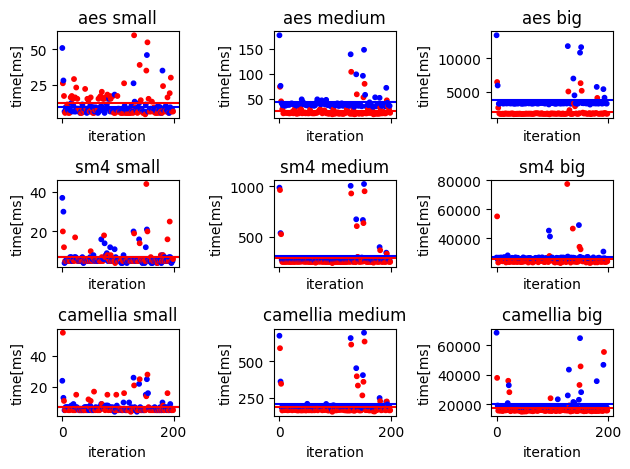

In [9]:
fig, axs = plt.subplots(3, 3, sharex = True,sharey=False)
create_plot("aes", "s", axs[0,0])
create_plot("aes", "m", axs[0,1])
create_plot("aes", "b", axs[0,2])
create_plot("sm4", "s", axs[1,0])
create_plot("sm4", "m", axs[1,1])
create_plot("sm4", "b", axs[1,2])
create_plot("camellia", "s", axs[2,0])
create_plot("camellia", "m", axs[2,1])
create_plot("camellia", "b", axs[2,2])
for ax in axs.flat:
    ax.set(xlabel='iteration', ylabel='time[ms]')
plt.tight_layout()
plt.show()

## Second Plot: bar plot
The pourpose of the following bar plots is to see a confrontation between the three algorithm and check how the difference between the threes changes as the filesize increases.
We can notice that aes is the fastest when we have medium and big file sizes, when we have small files is slower that the other two, both for encryption and decryption.
Another thing we can notice is that the difference between medium and big seems to stay constant, that's not really true because the plot scale changes, we can think that depends on a linear relation.


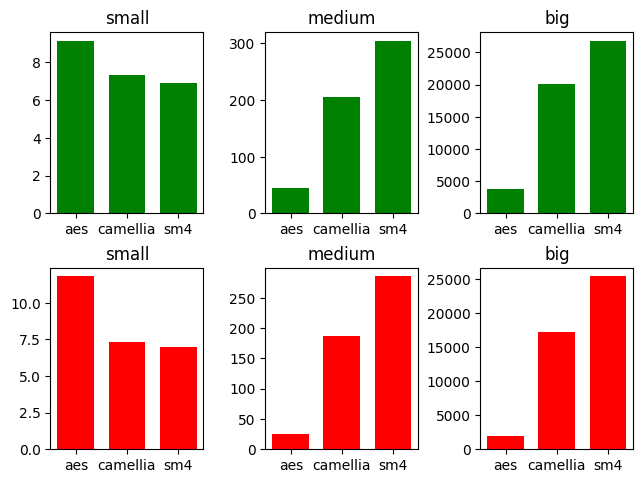

In [10]:
def plot_means():
    fig, axs = plt.subplots(2,3);
    i = 0
    for file_size in ['s', 'm', 'b']:
        enc_mean = []
        dec_mean = []
        algor = []
        for algo in ['aes', 'camellia', 'sm4']:
            Y = [(int(rows[1]), 'b' if rows[3] == 'e' else 'r') for rows in datas if (rows[0].strip() == algo and rows[2].strip() == file_size )]
            enc_mean.append(mean([y[0] for y in Y if y[1] == 'b']))
            dec_mean.append(mean([y[0] for y in Y if y[1] == 'r']))
            algor.append(algo)
            
        axs[0, i].bar(algor, enc_mean, color = 'g', width = 0.72, label = "Algorithm")
        axs[0, i].set_title(f'{d[file_size]}')
        axs[1, i].bar(algor, dec_mean, color = 'r', width = 0.72, label = "Algorithm")
        axs[1, i].set_title(f'{d[file_size]}')
        i+=1
    plt.tight_layout(pad = 0.6)
plot_means()
plt.show()

    

## Third plot: line plot
To show the relation between file increasing and time need to encrypt/decrypt is well shown by a simple function.
This confirms that the most efficent algoritm for decryption is aes, we've already seen this in the first figure but now we have a clearer view. Instead we can see that sm4 is the algoritm that has less difference between encryption and decryption time.

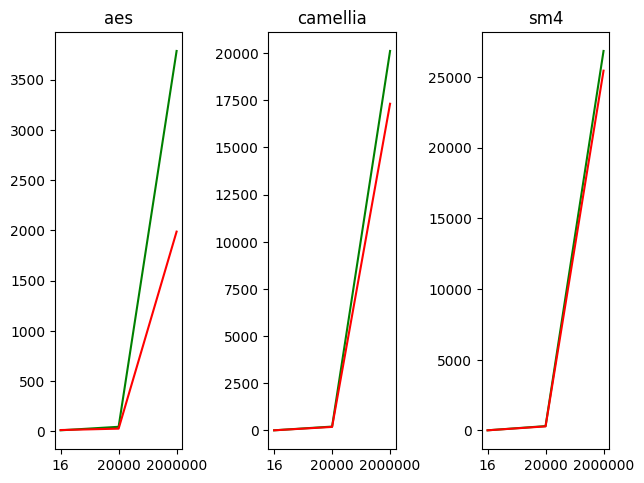

In [16]:
def plot_size_time():
    fig, axs = plt.subplots(1,3);
    i = 0
    for algo in ['aes', 'camellia', 'sm4']:
        d2 = {'s': 16, 'm': 20000, 'b': '2000000'}
        enc_mean = []
        dec_mean = []
        X = []
        for file_size in ['s', 'm', 'b']:    
            Y = [(int(rows[1]), 'b' if rows[3] == 'e' else 'r') for rows in datas if (rows[0].strip() == algo and rows[2].strip() == file_size )]
            enc_mean.append(mean([y[0] for y in Y if y[1] == 'b']))
            dec_mean.append(mean([y[0] for y in Y if y[1] == 'r']))
            X.append(d2[file_size])
            
        axs[i].plot(X, enc_mean, color = 'g', label = "Algorithm")
        axs[i].set_title(f'{algo}')
        axs[i].plot(X, dec_mean, color = 'r', label = "Algorithm")
        i+=1
    plt.tight_layout(pad = 0.6)
plot_size_time()
plt.show()

## Conclusion
If I had to choose I would choose the AES algorithm, given this plots we can clearly see how it'is faster than the other, in particular increasing file size, and he has the higher difference between encryption time and decryption time, that's crucial for a lot of applications that involve more decryption than encryption, clearly the opposit is difficult because if I encrypt a file I probabily want also to decrypt it. 

##### Source code
the complete source code is at this [github repo](https://github.com/tizianocoluzzi/homework_cybersec.git)